In [1]:
import matplotlib.pyplot as plt
import scienceplots
plt.style.use(['science', 'nature', 'grid'])

from matplotlib.lines import Line2D

import string

import pandas as pd
import numpy as np
from scipy.integrate import quad

In [2]:
# Matplotlib settings
WIDTH = 6.0 
HEIGHT = 5.0

plt.rcParams.update({
    "figure.figsize": (.5*WIDTH, .5*HEIGHT),
    "font.size": 10,           # Matches thesis 10pt
    "axes.labelsize": 10,
    "legend.fontsize": 8,      # Slightly smaller for legends
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "lines.linewidth": 1,
    "lines.markersize": 4,
    "savefig.bbox": 'tight',   # Ensures no labels are cut off
    "savefig.pad_inches": 0.05
})

# Bimodal

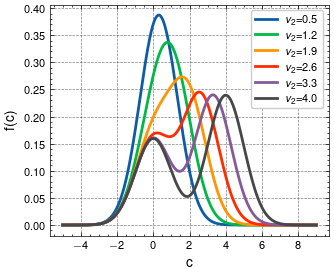

In [4]:
# Mathematica translation - assume to know the distribution
# --- bimodal distribution ---
def fbimodal(rho1_bimodal, v1_bimodal, theta1_bimodal, rho2_bimodal, v2_bimodal, theta2_bimodal, c):
    term1 = (rho1_bimodal / np.sqrt(2 * np.pi * theta1_bimodal)) * np.exp(-(c - v1_bimodal) ** 2 / (2 * theta1_bimodal))
    term2 = (rho2_bimodal / np.sqrt(2 * np.pi * theta2_bimodal)) * np.exp(-(c - v2_bimodal) ** 2 / (2 * theta2_bimodal))
    return term1 + term2

# --- fixed parameters ---
rho1_bimodal = 40 / 100
v1_bimodal = 0
theta1_bimodal = 100 / 100
rho2_bimodal = 60 / 100
theta2_bimodal = 10 / 10

# underlying distribution with fixed parameters
def fhid(c, v2):
    return fbimodal(rho1_bimodal, v1_bimodal, theta1_bimodal, rho2_bimodal, v2, theta2_bimodal, c)

# --- plotting dependence on v2 ---
def plot_family():
    fig, ax = plt.subplots()
    c_vals = np.linspace(-5, 9, 500)
    for v2 in np.linspace(0.5, 4, 6):
        ax.plot(c_vals, [fhid(c, v2) for c in c_vals], linewidth=2, label=f"$v_2$={v2:.1f}")
    ax.legend()
    ax.set_xlabel("c")
    ax.set_ylabel("f(c)")
    plt.show()

# --- moments ---
def uhid(v2, Mmax):
    """Compute first Mmax+2 raw moments (0..Mmax+1)."""
    moments = []
    for k in range(Mmax + 2):
        integrand = lambda c: (c ** k) * fhid(c, v2)
        val, _ = quad(integrand, -np.inf, np.inf)
        moments.append(val)
    return np.array(moments)

def momList(M, v2):
    """Return first M+1 moments."""
    return uhid(v2, M)[:M+1]

def uhidnextmoment(M, v2):
    """Return moment of order M+1."""
    return uhid(v2, M)[M+1]

# plot_family()

fig, ax = plt.subplots(figsize=(0.6*WIDTH, 0.6*HEIGHT))
c_vals = np.linspace(-5, 9, 500)
for v2 in np.linspace(0.5, 4, 6):
    ax.plot(c_vals, [fhid(c, v2) for c in c_vals], linewidth=2, label=f"$v_2$={v2:.1f}")
ax.legend()
ax.set_xlabel("c")
ax.set_ylabel("f(c)")
fig.savefig("../out/Figures/CompareClosure/BimodalFamily.pdf")
plt.show()

# Chosen plots for Thesis

In [9]:
closures = [
    "Gram",
    "ExtGram",
    "Grad"
]

Moments_even = np.array([4, 12])
Moments_odd = Moments_even + 1

v2_vector = [2.0, 3.0]
M_even_v2 = np.arange(4, 25, 2, dtype=int)
M_odd_v2 = M_even_v2 + 1

colors = ['blue', 'red', 'green']
marker = ['-x', '-o', '-^']

labels = string.ascii_lowercase

/var/folders/v_/5q1gkdc53z34pdsfnpkx2t340000gn/T/ipykernel_32157/1777658150.py:20: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
/var/folders/v_/5q1gkdc53z34pdsfnpkx2t340000gn/T/ipykernel_32157/1777658150.py:20: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
/var/folders/v_/5q1gkdc53z34pdsfnpkx2t340000gn/T/ipykernel_32157/1777658150.py:42: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
/var/folders/v_/5q1gkdc53z34pdsfnpkx2t340000gn/T/ipykernel_32157/1777658150.py:42: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


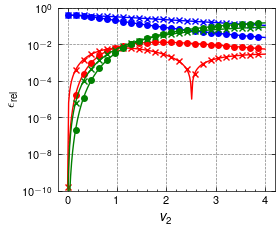

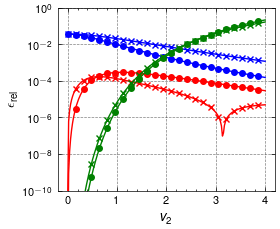

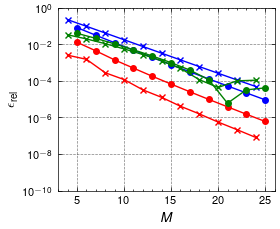

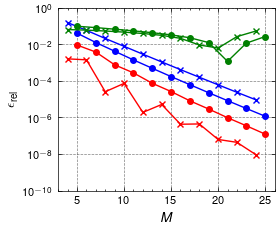

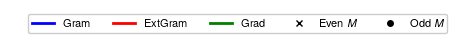

In [10]:
# Plotting for fixed M
for plot_index, (M_even, M_odd) in enumerate(zip(Moments_even, Moments_odd)):
    fig, axs = plt.subplots()
    for i, closure in enumerate(closures):
        file_even = f"../out/CompareClosure/Accuracy_over_v2_closure_{closure}_M{M_even}.csv"
        data_even = pd.read_csv(file_even)
        axs.semilogy(data_even['v2_vector'], data_even['rel_err'], marker[0], markevery=8, color=colors[i])
    
        file_odd = f"../out/CompareClosure/Accuracy_over_v2_closure_{closure}_M{M_odd}.csv"
        data_odd = pd.read_csv(file_odd)
        axs.semilogy(data_odd['v2_vector'], data_odd['rel_err'], marker[1], markevery=8, color=colors[i])

    axs.set_ylim(1e-10, 1e0)
    # axs.set_title(f'$M_{{even}}={M_even}, M_{{odd}}={M_odd}$')
    axs.set_xlabel(r'$v_2$')
    axs.set_ylabel(r'$\epsilon_{\text{rel}}$')

    fig.tight_layout()
    fig.savefig(f'../out/Figures/CompareClosure/CompareClosure_Meven{M_even}_Modd{M_odd}.pdf', bbox_inches='tight')
    fig.show()

# Plotting for fixed v2
for plot_index, v2 in enumerate(v2_vector):
    fig, axs = plt.subplots()
    for i, closure in enumerate(closures):
        file_even = f"../out/CompareClosure/Accuracy_over_EvenMoments_closure_{closure}_v2{v2}.csv"
        data_even = pd.read_csv(file_even)

        axs.semilogy(data_even['M_vector'], data_even['rel_err'], marker[0], color=colors[i])

        file_odd = f"../out/CompareClosure/Accuracy_over_OddMoments_closure_{closure}_v2{v2}.csv"
        data_odd = pd.read_csv(file_odd)

        axs.semilogy(data_odd['M_vector'], data_odd['rel_err'], marker[1], color=colors[i])
        
    axs.set_ylim(1e-10, 1e0)
    axs.set_xlabel(r'$M$')
    axs.set_ylabel(r'$\epsilon_{\text{rel}}$')

    fig.tight_layout()
    fig.savefig(f'../out/Figures/CompareClosure/CompareClosure_M_v2_{v2}.pdf', bbox_inches='tight')
    fig.show()

# Define the handles for each row separately
legend_elements = [
    Line2D([0], [0], color='blue', lw=2, label='Gram'),
    Line2D([0], [0], color='red', lw=2, label='ExtGram'),
    Line2D([0], [0], color='green', lw=2, label='Grad'),
    Line2D([0], [0], color='black', marker='x', lw=0, label='Even $M$'),
    Line2D([0], [0], color='black', marker='o', lw=0, label='Odd $M$'),
]

# To save JUST the legend as a separate file
fig_leg = plt.figure(figsize=(WIDTH, 0.5))
ax_leg = fig_leg.add_subplot(111)
ax_leg.axis('off')
# Grab handles from one of your existing axes
handles, labels = axs.get_legend_handles_labels()
ax_leg.legend(handles=legend_elements, loc='center', ncol=5)
fig_leg.savefig('../out/Figures/CompareClosure/legend_horizontal.pdf')